# Тестовое задание 1: Анализ финансовых транзакций и клиентов

# 0. Импорты

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Очистка и подготовка данных

Прочитаем и проверим данные о клиентах

In [29]:
clients = pd.read_json('clients_data.json')
clients_initial_len = len(clients)

print(clients.info())
print(clients.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9799 entries, 0 to 9798
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         9798 non-null   str    
 1   age        8816 non-null   float64
 2   gender     6480 non-null   str    
 3   net_worth  9324 non-null   float64
dtypes: float64(2), str(2)
memory usage: 306.3 KB
None
id              1
age           983
gender       3319
net_worth     475
dtype: int64


Видим, что есть пустые значения в полях 'id', 'age', 'gender' и 'net_worth'

В данном случае почистим все кроме 'gender' (его заменим на 'не указан'), так как отсутствие пола это не очень критично (например, человек при регистрации предпочел не указывать), и таких строк много (~30% от всего объема)

Так же почистим дубликаты и аномалии возраста и net worth, и переименуем 'id' в 'client_id'

In [30]:
clients = clients.dropna(subset=['id', 'age', 'net_worth'])

clients = clients.drop_duplicates(subset=['id'])

clients = clients[(clients['age'] >= 18) & (clients['age'] <= 100)]
clients = clients[clients['net_worth'] >= 0]

clients['gender'] = clients['gender'].fillna('не указан')
clients['gender'] = clients['gender'].str.strip().str.lower()

clients = clients.rename(columns={'id': 'client_id'})

clients_final_len = len(clients)
print(f"Удалено строк: {clients_initial_len - clients_final_len}")
print(f"Осталось клиентов: {clients_final_len}")

Удалено строк: 1423
Осталось клиентов: 8376


Возьмем из данных существующие id для проверки транзакций

In [31]:
valid_ids = set(clients['client_id'])

Теперь прочитаем и проверим информацию о данных транзакций

In [32]:
transactions = pd.read_excel('transactions_data.xlsx')
transactions_initial_len = len(transactions)

print(transactions.info())
print(transactions.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    9526 non-null   str    
 1   client_id         9798 non-null   str    
 2   transaction_date  10000 non-null  object 
 3   service           10000 non-null  str    
 4   amount            9540 non-null   float64
 5   payment_method    10000 non-null  str    
 6   city              10000 non-null  str    
 7   consultant        10000 non-null  str    
dtypes: float64(1), object(1), str(6)
memory usage: 625.1+ KB
None
transaction_id      474
client_id           202
transaction_date      0
service               0
amount              460
payment_method        0
city                  0
consultant            0
dtype: int64


Видим, что в полях 'transaction_id', 'client_id', 'amount' есть пустые значения, почистим их

Заодно уберем строки с несуществующими 'client_id', с отрицательными суммами, приведем все даты к единому формату и удалим дубликаты строк по 'transaction_id'

In [33]:
transactions.dropna(subset=['transaction_id', 'client_id', 'amount'], inplace=True)

transactions = transactions[transactions['client_id'].isin(valid_ids)]

transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'], errors='coerce')
transactions.dropna(subset=['transaction_date'], inplace=True)

transactions = transactions[transactions['amount'] >= 0]

transactions['amount'] = transactions['amount'].astype(float)

transactions.drop_duplicates(subset=['transaction_id'], inplace=True)

transactions_mid_len = len(transactions)
print(f"Удалено строк: {transactions_initial_len - transactions_mid_len}")
print(f"Осталось транзакций: {transactions_mid_len}")

Удалено строк: 3183
Осталось транзакций: 6817


Так же проверим поля 'service', 'payment_method', 'city', 'consultant' на аномальные значения, предварительно приведя к одному виду

In [34]:
transactions['service'] = transactions['service'].str.strip().str.lower()
transactions['payment_method'] = transactions['payment_method'].str.strip().str.lower()
transactions['city'] = transactions['city'].str.strip().str.lower()
transactions['consultant'] = transactions['consultant'].str.strip().str.lower()

print("Уникальные значения в поле 'service':")
print(transactions['service'].unique())

print("\nУникальные значения в поле 'payment_method':")
print(transactions['payment_method'].unique())

print("\nУникальные значения в поле 'city':")
print(transactions['city'].unique())

print("\nУникальные значения в поле 'consultant':")
print(transactions['consultant'].unique())

Уникальные значения в поле 'service':
<StringArray>
[      'структурирование капитала', 'инвестиционное консультирование',
              'неизвестная услуга',          'налоговое планирование',
             'управление активами',         'финансовое планирование']
Length: 6, dtype: str

Уникальные значения в поле 'payment_method':
<StringArray>
['банковский перевод',         'неизвестно',    'кредитная карта',
       'криптовалюта',           'наличные']
Length: 5, dtype: str

Уникальные значения в поле 'city':
<StringArray>
[ 'north patrickport',    'new zacharyport', 'port michellemouth',
           'bondstad',      'west jaymouth',        'johnsonfort',
           'tonystad',        'ronaldville',     'elizabethmouth',
      'matthewsville',   'north lauriebury',  'lake sallychester',
       'south andrew',       'hamiltontown',         'davidmouth',
    'lake arielmouth',          'lake tina',        'krystalland',
       'south thomas',          'erichaven',  'north hannahmouth',


Видим, что присутствуют аномальные данные:

- 'неизвестная услуга' в 'service'
- 'неизвестно' в 'payment_method'
- 'неизвестный город' в 'city'
- 'неизвестный консультант' в 'consultant'

Их тоже почистим (возможно, в зависимости от ситуации, их можно было бы считать валидными, но тут, за отсутствием конкретных требований по этому поводу, приму за шум)

In [35]:
invalid_services = [
    'неизвестная услуга'
]

invalid_methods = [
    'неизвестно'
]

invalid_cities = [
    'неизвестный город'
]

invalid_consultants = [
    'неизвестный консультант'
]

transactions = transactions[~transactions['service'].isin(invalid_services)]
transactions = transactions[~transactions['payment_method'].isin(invalid_methods)]
transactions = transactions[~transactions['city'].isin(invalid_cities)]
transactions = transactions[~transactions['consultant'].isin(invalid_consultants)]

print("После очистки:")
print("Услуги:", transactions['service'].unique())
print("Способы оплаты:", transactions['payment_method'].unique())
print("Города:", transactions['city'].unique())
print("Консультанты:", transactions['consultant'].unique())

После очистки:
Услуги: <StringArray>
[      'структурирование капитала', 'инвестиционное консультирование',
          'налоговое планирование',             'управление активами',
         'финансовое планирование']
Length: 5, dtype: str
Способы оплаты: <StringArray>
['банковский перевод', 'кредитная карта', 'криптовалюта', 'наличные']
Length: 4, dtype: str
Города: <StringArray>
[ 'north patrickport',      'west jaymouth',           'tonystad',
        'ronaldville',     'elizabethmouth',        'johnsonfort',
      'matthewsville',  'lake sallychester',       'south andrew',
         'davidmouth',   'north lauriebury',    'lake arielmouth',
        'krystalland',       'south thomas',       'hamiltontown',
          'erichaven', 'west meredithhaven',        'trevinoberg',
           'cruzport',  'north melissaland',           'new ryan',
          'patelbury',      'michellehaven',           'mayoberg',
         'harrisberg',         'roberttown',          'lake tina',
  'east melissav

Посмотрим, сколько всего мы почистили

In [36]:
transactions_final_len = len(transactions)
print(f"Удалено строк: {transactions_initial_len - transactions_final_len}")
print(f"Осталось транзакций: {transactions_final_len}")
print(f"Уникальных клиентов: {transactions['client_id'].nunique()}")
print(f"Период: {transactions['transaction_date'].min()} - {transactions['transaction_date'].max()}")

Удалено строк: 4888
Осталось транзакций: 5112
Уникальных клиентов: 5112
Период: 2025-01-01 00:45:37 - 2025-03-20 12:26:18


## 2. Анализ данных.

### 2.1 Топ-5 наиболее популярных услуг по количеству заказов

In [37]:
top5_services = transactions['service'].str.capitalize().value_counts().head(5)
print("Топ-5 услуг по количеству заказов:")
print(top5_services)

top5_services_p = transactions['service'].str.capitalize().value_counts(normalize=True).head(5) * 100
print("\nДоля от всех транзакций (%):")
print(top5_services_p.round(2))

Топ-5 услуг по количеству заказов:
service
Инвестиционное консультирование    1412
Управление активами                1119
Налоговое планирование              873
Финансовое планирование             862
Структурирование капитала           846
Name: count, dtype: int64

Доля от всех транзакций (%):
service
Инвестиционное консультирование    27.62
Управление активами                21.89
Налоговое планирование             17.08
Финансовое планирование            16.86
Структурирование капитала          16.55
Name: proportion, dtype: float64


### 2.2 Средняя сумма транзакций по каждому городу

In [38]:
avg_amount_by_city = transactions.groupby('city')['amount'].mean().sort_values(ascending=False)
print("Средняя сумма транзакций по городам:")
print(avg_amount_by_city)

Средняя сумма транзакций по городам:
city
east rachelmouth      56393.181332
port michellemouth    56184.640780
michellehaven         55619.952057
new tommyborough      55450.352199
krystalland           54479.710502
bondstad              54248.195992
kaneburgh             54120.760980
north lauriebury      53983.482353
lake tina             53949.156442
trevinoberg           53108.006468
erichaven             52412.912441
mayoberg              52242.339521
south andrew          52239.476650
new zacharyport       52160.312105
lake arielmouth       51777.619944
patelbury             51741.797468
west meredithhaven    51469.312226
port james            51134.309507
hamiltontown          51033.998202
johnsonfort           50838.330235
davidsonborough       50455.606054
east matthewmouth     50203.834970
north emily           50188.705912
port jordan           50028.994895
north melissaland     49869.482874
harrisberg            49609.169696
east melissaville     49229.698133
ronaldville  

### 2.3 Услуга с наибольшей выручкой (по сумме amount)

In [39]:
revenue_by_service = transactions.groupby('service')['amount'].sum()
top_service = revenue_by_service.idxmax().capitalize()
max_revenue = revenue_by_service.max()
print(f"Услуга с наибольшей выручкой: '{top_service}' (общая выручка: {max_revenue:,.2f})")

Услуга с наибольшей выручкой: 'Инвестиционное консультирование' (общая выручка: 71,079,891.33)


### 2.4 Процент транзакций по способам оплаты

In [40]:
payment_summary = pd.DataFrame({
    'Количество': transactions['payment_method'].str.capitalize().value_counts(),
    'Доля (%)': transactions['payment_method'].str.capitalize().value_counts(normalize=True).round(2) * 100
})
print(payment_summary)

                    Количество  Доля (%)
payment_method                          
Кредитная карта           2282      45.0
Банковский перевод        1973      39.0
Наличные                   554      11.0
Криптовалюта               303       6.0


### 2.5 Выручка за последний месяц

In [41]:
min_date = transactions['transaction_date'].min()
max_date = transactions['transaction_date'].max()

last_full_month = max_date - pd.offsets.MonthEnd(1)
month_start = last_full_month.replace(day=1)
month_end = last_full_month

mask_last_month = (transactions['transaction_date'] >= month_start) & (transactions['transaction_date'] <= month_end)
revenue_last_month = transactions.loc[mask_last_month, 'amount'].sum()

print(f"Минимальная дата: {min_date.date()}")
print(f"Максимальная дата: {max_date.date()}")
print(f"Последний полный месяц: {month_start.strftime('%B %Y')}")
print(f"Выручка за последний полный месяц: {revenue_last_month:,.2f}")

Минимальная дата: 2025-01-01
Максимальная дата: 2025-03-20
Последний полный месяц: February 2025
Выручка за последний полный месяц: 83,169,801.66


## 3. Объединение данных.

### 3.1 Объединение транзакций с клиентами

In [42]:
merged = transactions.merge(clients, on='client_id', how='inner')
print(f"Объединённая таблица: {merged.shape[0]} строк, {merged.shape[1]} столбцов")
print(f"Уникальных клиентов: {merged['client_id'].nunique()}")

Объединённая таблица: 5112 строк, 11 столбцов
Уникальных клиентов: 5112


### 3.2 Создание категории по уровню капитала

In [43]:
def get_asset_level(net_worth):
    if net_worth < 100_000:
        return 'Низкий капитал'
    elif 100_000 <= net_worth <= 1_000_000:
        return 'Средний капитал'
    else:
        return 'Высокий капитал'

merged['asset_level'] = merged['net_worth'].apply(get_asset_level)

print("Распределение записей по уровням капитала:")
print(merged['asset_level'].value_counts())

Распределение записей по уровням капитала:
asset_level
Высокий капитал    4136
Средний капитал     881
Низкий капитал       95
Name: count, dtype: int64


### 3.3 Анализ выручки по уровням активов

In [44]:
revenue_by_asset = merged.groupby('asset_level')['amount'].sum().sort_values(ascending=False)
print("Выручка по уровням активов:")
print(revenue_by_asset.apply(lambda x: f"{x:,.2f}"))

top_asset = revenue_by_asset.idxmax()
print(f"\nНаибольшую выручку приносят клиенты с категорией: '{top_asset}'")

asset_summary = merged.groupby('asset_level').agg(
    total_revenue=('amount', 'sum'),
    avg_transaction=('amount', 'mean'),
    transactions_count=('amount', 'count'),
    unique_clients=('client_id', 'nunique')
)
print("\nПолная сводка по уровням активов:")
print(asset_summary)

Выручка по уровням активов:
asset_level
Высокий капитал    205,515,867.66
Средний капитал     43,253,498.95
Низкий капитал       4,294,321.52
Name: amount, dtype: str

Наибольшую выручку приносят клиенты с категорией: 'Высокий капитал'

Полная сводка по уровням активов:
                 total_revenue  avg_transaction  transactions_count  \
asset_level                                                           
Высокий капитал   2.055159e+08     49689.523127                4136   
Низкий капитал    4.294322e+06     45203.384425                  95   
Средний капитал   4.325350e+07     49095.912540                 881   

                 unique_clients  
asset_level                      
Высокий капитал            4136  
Низкий капитал               95  
Средний капитал             881  


## 4. Визуализация данных

### 4.1 Распределение сумм транзакций

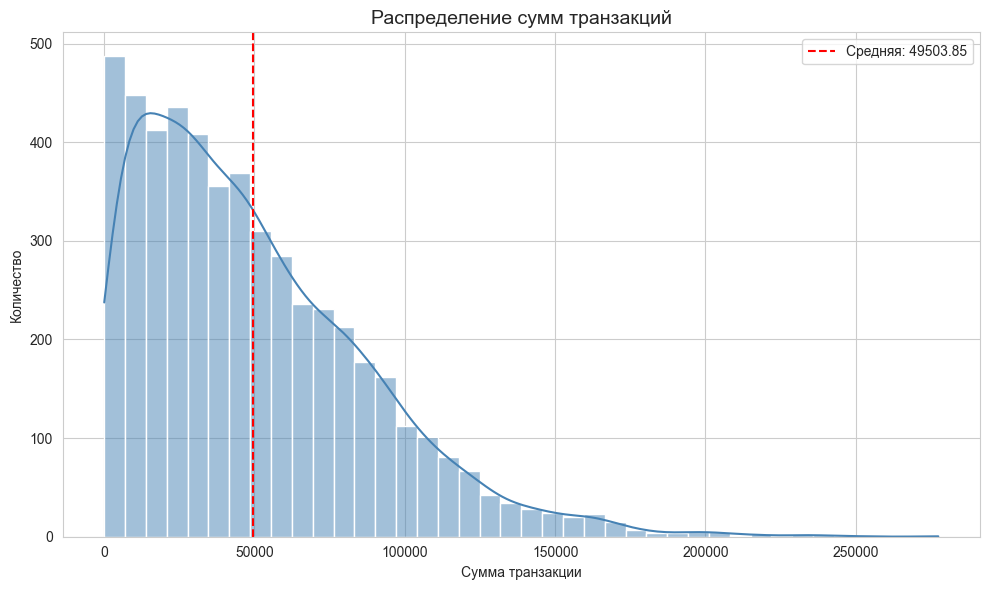

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(transactions['amount'], bins=40, kde=True, color='steelblue', edgecolor='white')
plt.title('Распределение сумм транзакций', fontsize=14)
plt.xlabel('Сумма транзакции')
plt.ylabel('Количество')
plt.axvline(transactions['amount'].mean(), color='red', linestyle='--', label=f"Средняя: {transactions['amount'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

### 4.1 Диаграмма выручки по услугам

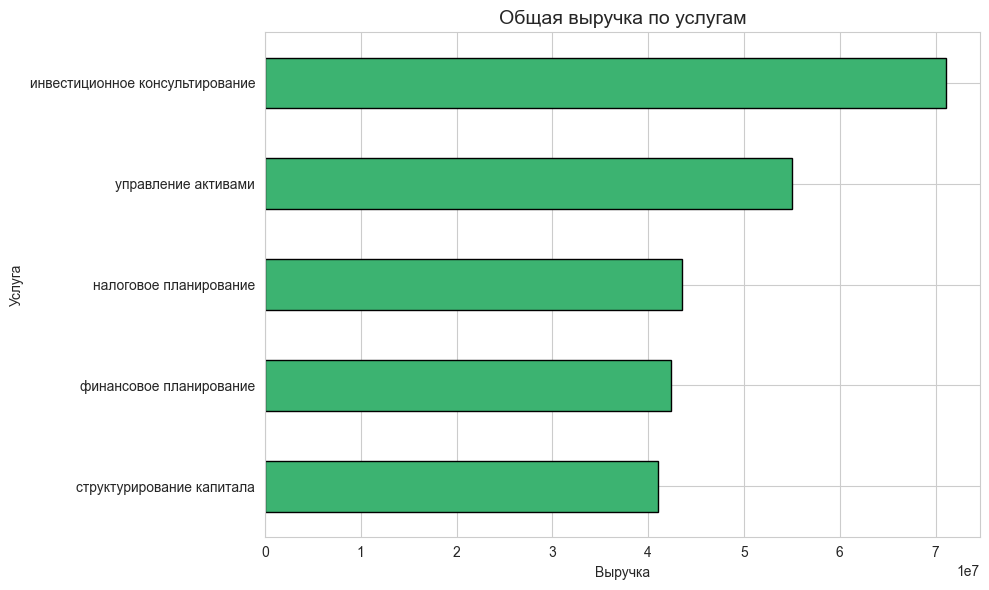

In [46]:
revenue_by_service = transactions.groupby('service')['amount'].sum().sort_values()

plt.figure(figsize=(10, 6))
revenue_by_service.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Общая выручка по услугам', fontsize=14)
plt.xlabel('Выручка')
plt.ylabel('Услуга')
plt.tight_layout()
plt.show()

### 4.3 Зависимость средней суммы транзакции от возраста клиентов

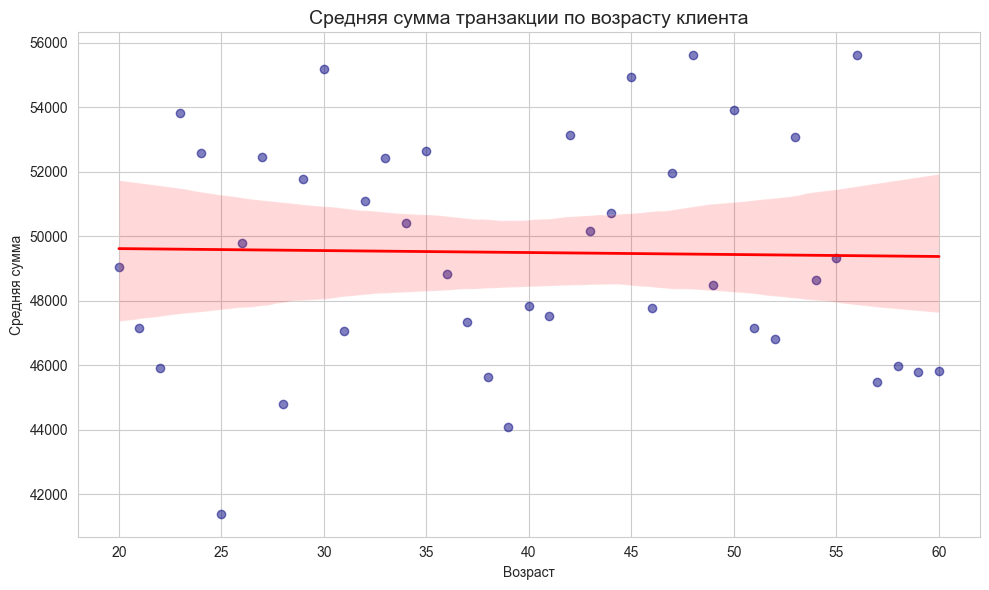

In [47]:
age_amount = merged.groupby('age')['amount'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.regplot(data=age_amount, x='age', y='amount',
            scatter_kws={'alpha':0.5, 'color':'navy'},
            line_kws={'color':'red', 'lw':2})
plt.title('Средняя сумма транзакции по возрасту клиента', fontsize=14)
plt.xlabel('Возраст')
plt.ylabel('Средняя сумма')
plt.tight_layout()
plt.show()

## 5. Прогнозирование

### 5.1 Прогнозирование выручки на следующий месяц (линейная регрессия)

Линейную регрессию будем делать по неделям, так как если делать ее по дням, получим плохой результат из-за отсутствия явных закономерностей в распределении выручки по дням, которое больше похоже на шум

Также нормируем выручку за последнюю неделю, так как она неполная и из-за этого имеет низкое значение выручки, что мешает регрессией посчитать правильный наклон прямой предсказания и наклоняет ее вниз

Последняя неделя (2025-12) неполная: 4 из 7 дней. Сумма нормирована до 20,712,695.01 (коэффициент 1.75)

Прогнозируемая выручка за следующий месяц:91,551,082.61


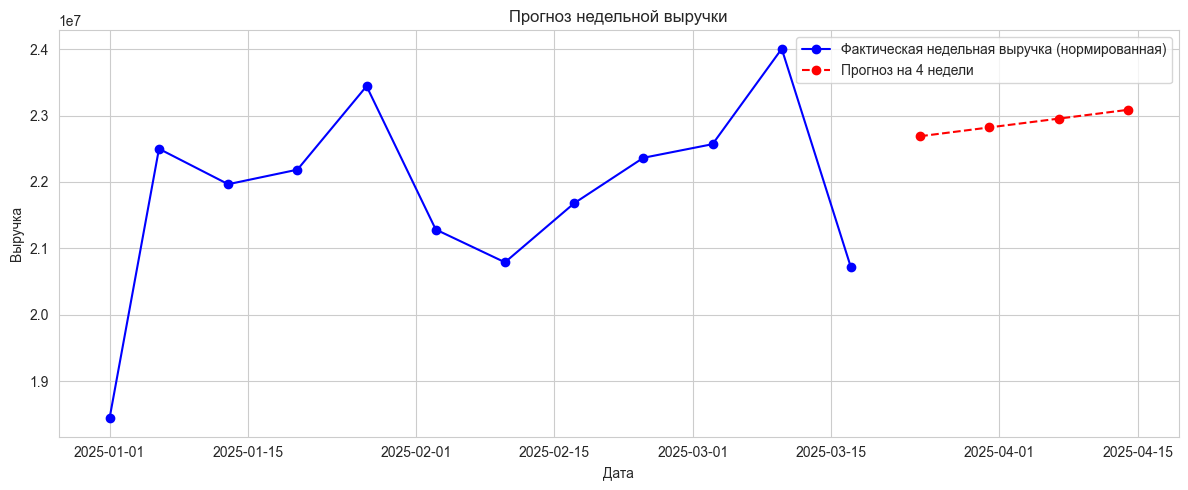

In [49]:
daily_revenue = transactions.groupby(
    transactions['transaction_date'].dt.date
)['amount'].sum().reset_index()

daily_revenue.rename(columns={'transaction_date': 'date'}, inplace=True)
daily_revenue['date'] = pd.to_datetime(daily_revenue['date'])
daily_revenue = daily_revenue.sort_values('date')

daily_revenue['year_week'] = daily_revenue['date'].dt.strftime('%G-%V')

days_in_week = (
    daily_revenue.groupby('year_week')['date']
    .nunique()
    .reset_index(name='days_count')
)

weekly_revenue = daily_revenue.groupby('year_week').agg(
    amount=('amount', 'sum'),
    week_start=('date', 'min')
).reset_index()

weekly_revenue = weekly_revenue.merge(days_in_week, on='year_week')
weekly_revenue = weekly_revenue.sort_values('week_start')

last_idx = weekly_revenue.index[-1]
last_days = weekly_revenue.loc[last_idx, 'days_count']
if last_days < 7:
    factor = 7 / last_days
    weekly_revenue.loc[last_idx, 'amount'] *= factor
    print(f"Последняя неделя ({weekly_revenue.loc[last_idx, 'year_week']}) неполная: "
          f"{int(last_days)} из 7 дней. Сумма нормирована до "
          f"{weekly_revenue.loc[last_idx, 'amount']:,.2f} (коэффициент {factor:.2f})\n")

weekly_revenue['week_num'] = range(len(weekly_revenue))

X = weekly_revenue[['week_num']].values
y = weekly_revenue['amount'].values
model = LinearRegression()
model.fit(X, y)

last_week_num = weekly_revenue['week_num'].max()
future_weeks = np.arange(last_week_num + 1, last_week_num + 5).reshape(-1, 1)
future_pred = model.predict(future_weeks)

predicted_monthly_revenue = future_pred.sum()
print(f"Прогнозируемая выручка за следующий месяц:"
      f"{predicted_monthly_revenue:,.2f}")

plt.figure(figsize=(12, 5))
plt.plot(weekly_revenue['week_start'], weekly_revenue['amount'],
         marker='o', label='Фактическая недельная выручка (нормированная)', color='blue')

last_date = weekly_revenue['week_start'].max()
future_dates = [last_date + pd.Timedelta(days=7 * i) for i in range(1, 5)]
plt.plot(future_dates, future_pred, 'o--', label='Прогноз на 4 недели', color='red')

plt.title('Прогноз недельной выручки')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.tight_layout()
plt.show()